In [ ]:

!pip install -q "datasets==2.19.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 16.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.24.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.24.0 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.24.0 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.24.0 which is incompatible.


In [ ]:
# Step 3: Load dataset
from datasets import load_dataset

dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_All_Beauty",
    trust_remote_code=True,
    split="full"
)

print(dataset)
print(dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating full split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'],
    num_rows: 701528
})
{'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': True}


In [ ]:
# Step 4: Convert to pandas and explore
df = dataset.to_pandas()

print(df.shape)
print(df.dtypes)
print(df.head())
print(df["rating"].value_counts())

(701528, 10)
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object
   rating                                      title  \
0     5.0  Such a lovely scent but not overpowering.   
1     4.0     Works great but smells a little weird.   
2     5.0                                       Yes!   
3     1.0                          Synthetic feeling   
4     5.0                                         A+   

                                                text images        asin  \
0  This spray is really nice. It smells really go...     []  B00YQ6X8EO   
1  This product does what I need it to do, I just...     []  B081TJ8YS3   
2                          Smells good, feels great!     []  B07PNNCSP9   
3                                     Felt syn

In [ ]:
df.head()        # first 5 rows
df.tail()        # last 5 rows
df.sample(5)     # random 5 rows

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
451289,5.0,You won't be disappointed. I love it.,I have thick hair and it tends to feel a littl...,[],B014AP7TZE,B07R1K1SBD,AE4ZQ44M5K5VKWDNR2HVRJRWBFDQ,1618263711114,0,True
66077,5.0,A terrific purchase!,"I love these. They are sturdy, well finished a...",[],B07BP1VCP6,B07T7TYRX1,AFB2B3F5OPULYJC3EXJBL7LQP2JQ,1543687781584,1,True
483278,5.0,Love this comb for my blow dryer,"Love this comb for my blow dryer , i work in a...",[],B008A12F36,B008A12F36,AGGK6BTEGFJZ52P2KZIUFCLDAQJQ,1456969993000,0,True
439852,5.0,Great product! Use it everyday,Bought this sponge for myself and my son. Grea...,[],B00TJ9UT7W,B00TJ9UT7W,AEEK5SGPQNU6DEHEVT5O5XYHZCJA,1474243652000,0,True
12500,1.0,Don’t buy unless your a pro or someone else wi...,Can’t get them on for the life of me.,[],B07NQFJZM1,B07NQFJZM1,AH7VVAYT7ED5H24ICNV64ECNZGPQ,1562713118059,0,True


In [ ]:
df.shape         # rows, columns
df.columns       # column names
df.dtypes        # data types
df.info()        # full summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701528 entries, 0 to 701527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   rating             701528 non-null  float64
 1   title              701528 non-null  object 
 2   text               701528 non-null  object 
 3   images             701528 non-null  object 
 4   asin               701528 non-null  object 
 5   parent_asin        701528 non-null  object 
 6   user_id            701528 non-null  object 
 7   timestamp          701528 non-null  int64  
 8   helpful_vote       701528 non-null  int64  
 9   verified_purchase  701528 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 48.8+ MB


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

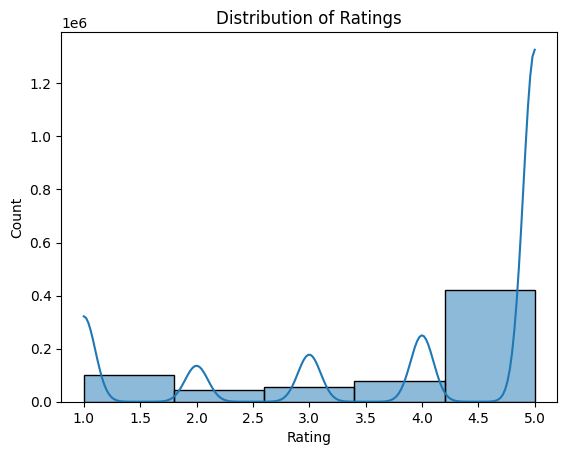

In [ ]:
sns.histplot(df["rating"], bins=5, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

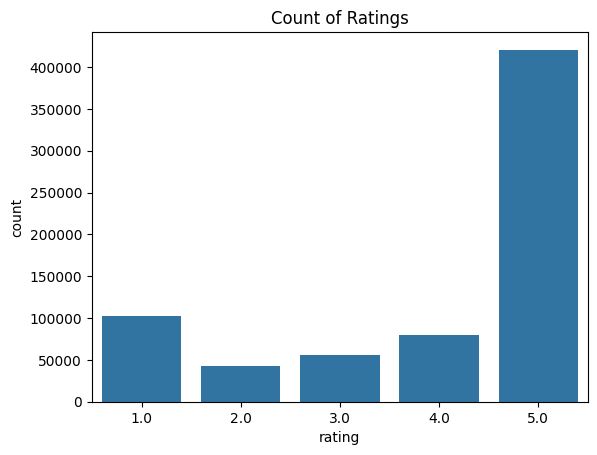

In [ ]:
sns.countplot(x="rating", data=df)
plt.title("Count of Ratings")
plt.show()

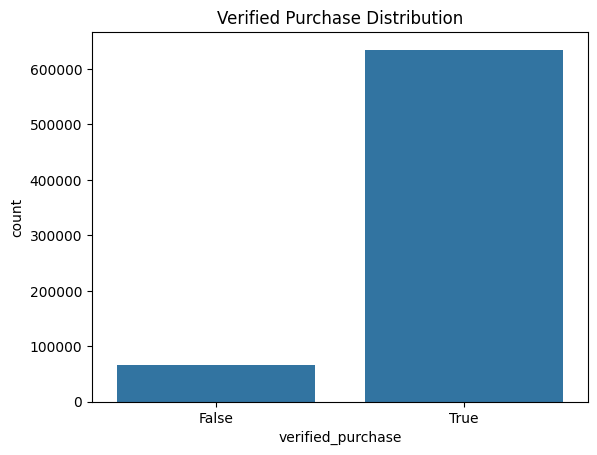

In [ ]:
sns.countplot(x="verified_purchase", data=df)
plt.title("Verified Purchase Distribution")
plt.show()

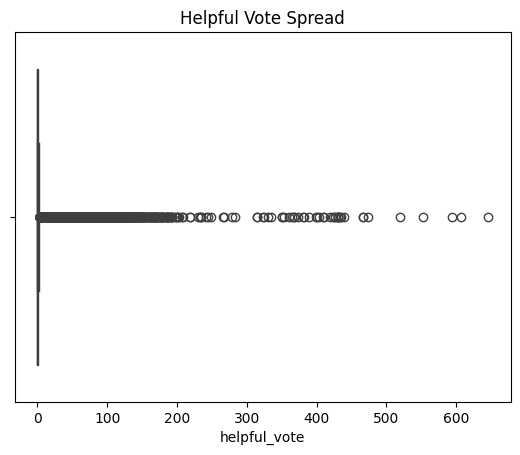

In [ ]:
sns.boxplot(x=df["helpful_vote"])
plt.title("Helpful Vote Spread")
plt.show()

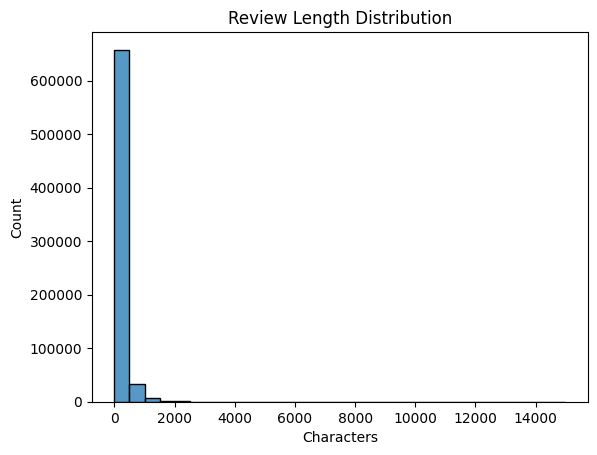

In [ ]:
df["review_length"] = df["text"].str.len()

sns.histplot(df["review_length"], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.show()

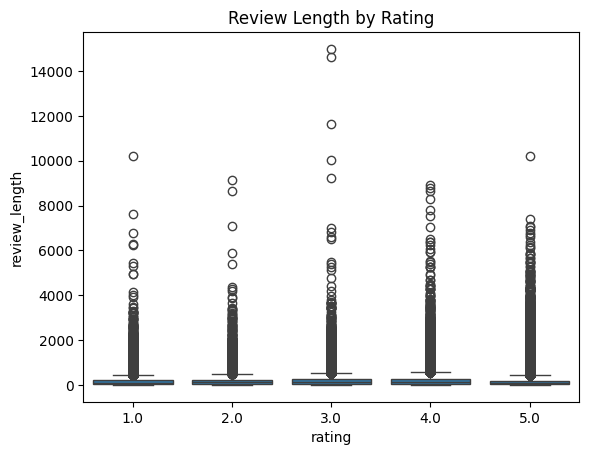

In [ ]:
sns.boxplot(x="rating", y="review_length", data=df)
plt.title("Review Length by Rating")
plt.show()

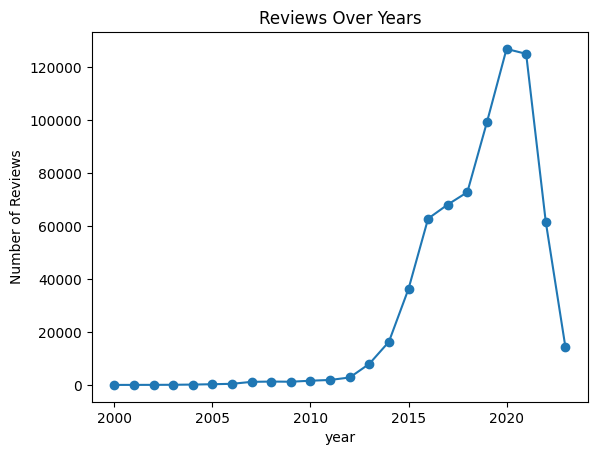

In [ ]:
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df["year"] = df["date"].dt.year

df.groupby("year").size().plot(kind="line", marker="o")
plt.title("Reviews Over Years")
plt.ylabel("Number of Reviews")
plt.show()

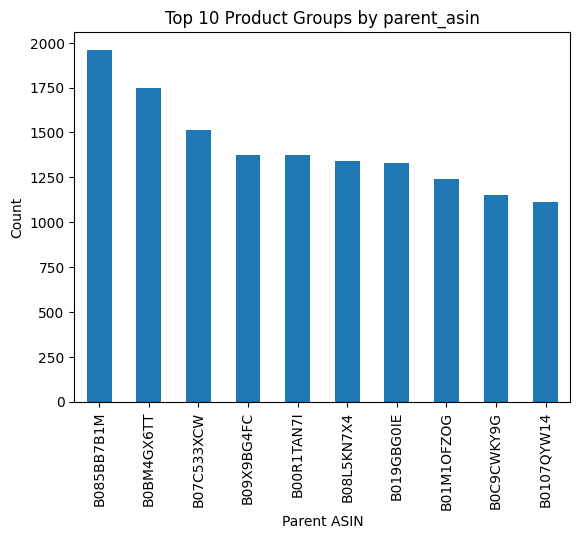

In [ ]:
top_categories = df["parent_asin"].value_counts().head(10)

top_categories.plot(kind="bar")
plt.title("Top 10 Product Groups by parent_asin")
plt.ylabel("Count")
plt.xlabel("Parent ASIN")
plt.show()

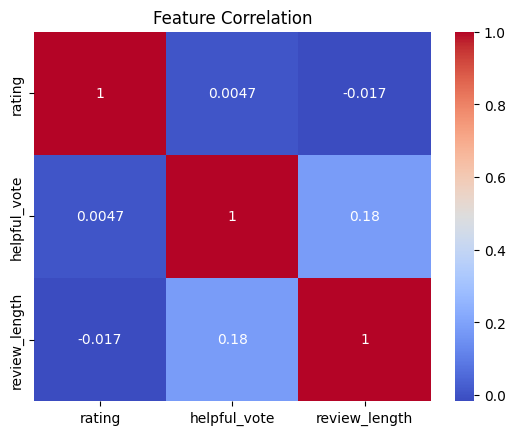

In [ ]:
corr = df[["rating", "helpful_vote", "review_length"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

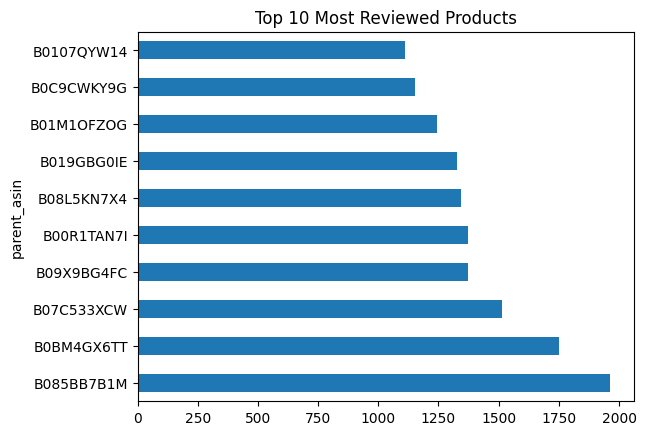

In [ ]:
top_products = df["parent_asin"].value_counts().head(10)

top_products.plot(kind="barh")
plt.title("Top 10 Most Reviewed Products")
plt.show()

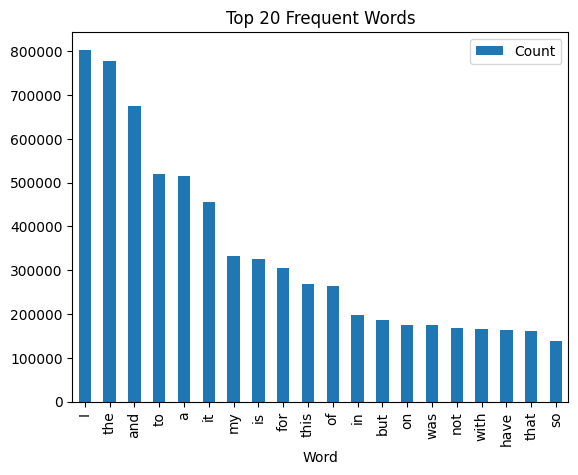

In [ ]:
from collections import Counter

words = " ".join(df["text"].dropna()).split()
common_words = Counter(words).most_common(20)

pd.DataFrame(common_words, columns=["Word","Count"]).plot(
    x="Word", y="Count", kind="bar"
)
plt.title("Top 20 Frequent Words")
plt.show()